In [1]:
# ============================================================
# PREDICTIVE MAINTENANCE & RUL ESTIMATION
# Dataset: NASA C-MAPSS (Turbofan Engine Degradation)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import shap
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [2]:
# ============================================================
# LOAD THE DATASET
# ============================================================

# Column names for C-MAPSS dataset
col_names = ['engine_id', 'cycle'] + \
            ['setting_1', 'setting_2', 'setting_3'] + \
            [f'sensor_{i}' for i in range(1, 22)]

# Load training data
train_df = pd.read_csv('data/train_FD001.txt', 
                        sep='\s+', 
                        header=None, 
                        names=col_names)

print("✅ Dataset loaded!")
print(f"📊 Shape: {train_df.shape}")
print(f"\n🔍 First 5 rows:")
train_df.head()

✅ Dataset loaded!
📊 Shape: (20631, 26)

🔍 First 5 rows:


,engine_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


📊 Dataset Info:
Total engines: 100
Total cycles: 362
Total rows: 20631
Total columns: 26

📈 Basic Statistics:
       engine_id     cycle  setting_1  setting_2  setting_3  sensor_1  \
count   20631.00  20631.00   20631.00    20631.0    20631.0  20631.00   
mean       51.51    108.81      -0.00        0.0      100.0    518.67   
std        29.23     68.88       0.00        0.0        0.0      0.00   
min         1.00      1.00      -0.01       -0.0      100.0    518.67   
25%        26.00     52.00      -0.00       -0.0      100.0    518.67   
50%        52.00    104.00       0.00        0.0      100.0    518.67   
75%        77.00    156.00       0.00        0.0      100.0    518.67   
max       100.00    362.00       0.01        0.0      100.0    518.67   

       sensor_2  sensor_3  sensor_4  sensor_5  ...  sensor_12  sensor_13  \
count  20631.00  20631.00  20631.00  20631.00  ...   20631.00   20631.00   
mean     642.68   1590.52   1408.93     14.62  ...     521.41    2388.10   
std 

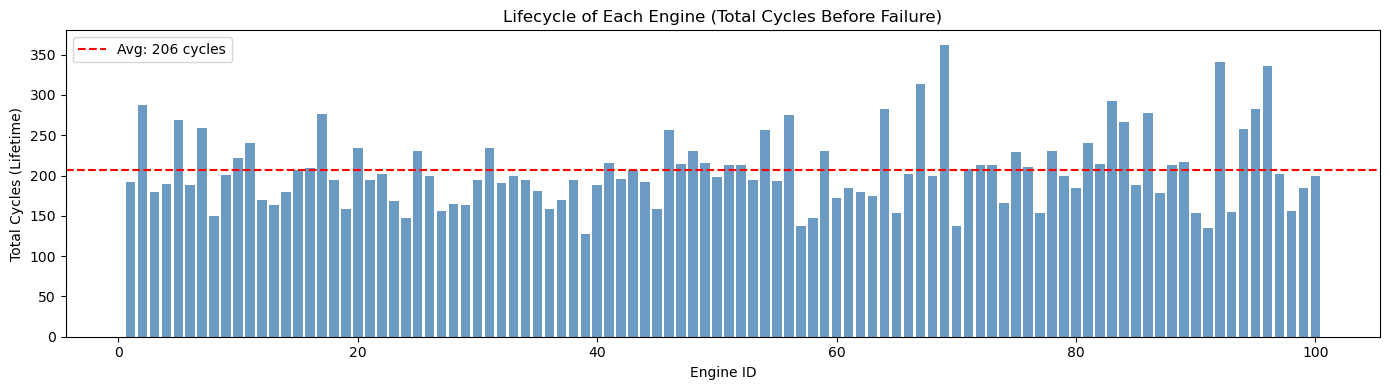


⚙️ Average engine life: 206 cycles
⚙️ Min engine life: 128 cycles
⚙️ Max engine life: 362 cycles


In [3]:
# ============================================================
# EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================

print("📊 Dataset Info:")
print(f"Total engines: {train_df['engine_id'].nunique()}")
print(f"Total cycles: {train_df['cycle'].max()}")
print(f"Total rows: {train_df.shape[0]}")
print(f"Total columns: {train_df.shape[1]}")

print("\n📈 Basic Statistics:")
print(train_df.describe().round(2))

print("\n🔍 Missing Values:")
print(train_df.isnull().sum().sum(), "missing values found")

# Visualise engine lifecycle — how long each engine ran
engine_life = train_df.groupby('engine_id')['cycle'].max()

plt.figure(figsize=(14, 4))
plt.bar(engine_life.index, engine_life.values, color='steelblue', alpha=0.8)
plt.xlabel('Engine ID')
plt.ylabel('Total Cycles (Lifetime)')
plt.title('Lifecycle of Each Engine (Total Cycles Before Failure)')
plt.axhline(engine_life.mean(), color='red', linestyle='--', label=f'Avg: {engine_life.mean():.0f} cycles')
plt.legend()
plt.tight_layout()
plt.show()

print(f"\n⚙️ Average engine life: {engine_life.mean():.0f} cycles")
print(f"⚙️ Min engine life: {engine_life.min()} cycles")
print(f"⚙️ Max engine life: {engine_life.max()} cycles")

✅ RUL computed successfully!

📊 RUL Statistics:
count    20631.00
mean       107.81
std         68.88
min          0.00
25%         51.00
50%        103.00
75%        155.00
max        361.00
Name: RUL, dtype: float64


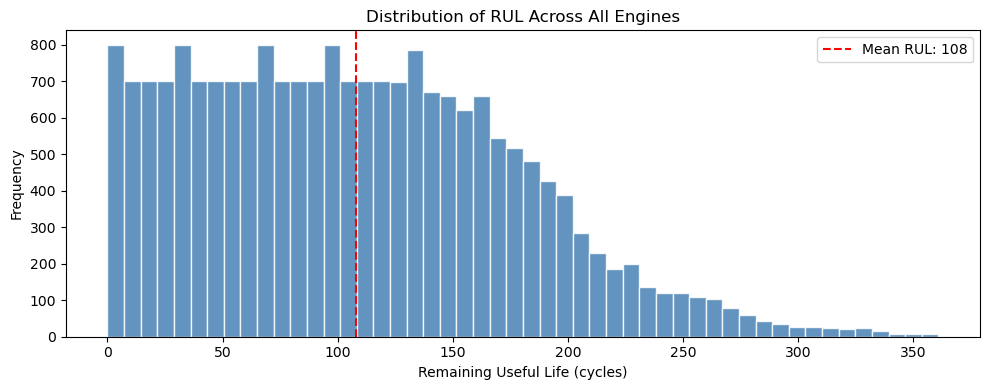


🔍 Sample — Engine 1 (first 5 rows):


,engine_id,cycle,RUL
0,1,1,191
1,1,2,190
2,1,3,189
3,1,4,188
4,1,5,187


In [4]:
# ============================================================
# COMPUTE REMAINING USEFUL LIFE (RUL)
# ============================================================

# RUL = how many cycles remaining before engine fails
# If engine ran 200 cycles total, at cycle 50 → RUL = 150

# Get max cycle for each engine (= total life)
max_cycles = train_df.groupby('engine_id')['cycle'].max().reset_index()
max_cycles.columns = ['engine_id', 'max_cycle']

# Merge back into main dataframe
train_df = train_df.merge(max_cycles, on='engine_id')

# RUL = max_cycle - current_cycle
train_df['RUL'] = train_df['max_cycle'] - train_df['cycle']

# Drop max_cycle (no longer needed)
train_df.drop(columns=['max_cycle'], inplace=True)

print("✅ RUL computed successfully!")
print(f"\n📊 RUL Statistics:")
print(train_df['RUL'].describe().round(2))

# Visualise RUL distribution
plt.figure(figsize=(10, 4))
plt.hist(train_df['RUL'], bins=50, color='steelblue', edgecolor='white', alpha=0.85)
plt.xlabel('Remaining Useful Life (cycles)')
plt.ylabel('Frequency')
plt.title('Distribution of RUL Across All Engines')
plt.axvline(train_df['RUL'].mean(), color='red', linestyle='--', 
            label=f"Mean RUL: {train_df['RUL'].mean():.0f}")
plt.legend()
plt.tight_layout()
plt.show()

# Show sample — engine 1
print("\n🔍 Sample — Engine 1 (first 5 rows):")
train_df[train_df['engine_id']==1][['engine_id','cycle','RUL']].head()

In [5]:
# ============================================================
# DROP ZERO-VARIANCE SENSORS + FEATURE ENGINEERING
# ============================================================

# Step 1: Drop sensors with zero/near-zero variance (they carry no info)
from sklearn.feature_selection import VarianceThreshold

sensor_cols = [f'sensor_{i}' for i in range(1, 22)]
setting_cols = ['setting_1', 'setting_2', 'setting_3']

# Check variance of each sensor
variances = train_df[sensor_cols].var()
print("📊 Sensor Variances:")
print(variances.round(4))

# Drop sensors with variance = 0
zero_var_sensors = variances[variances == 0].index.tolist()
print(f"\n🗑️ Dropping zero-variance sensors: {zero_var_sensors}")
train_df.drop(columns=zero_var_sensors + setting_cols, inplace=True)

# Update sensor columns list
remaining_sensors = [c for c in sensor_cols if c not in zero_var_sensors]
print(f"✅ Remaining sensors: {remaining_sensors}")

# Step 2: Feature Engineering — Rolling statistics (window=5 cycles)
# This captures TREND — is the sensor getting worse over time?
print("\n⚙️ Engineering rolling features...")

for sensor in remaining_sensors:
    # Rolling mean — smooths out noise
    train_df[f'{sensor}_roll_mean'] = train_df.groupby('engine_id')[sensor]\
                                      .transform(lambda x: x.rolling(5, min_periods=1).mean())
    # Rolling std — captures how erratic the sensor is becoming
    train_df[f'{sensor}_roll_std'] = train_df.groupby('engine_id')[sensor]\
                                     .transform(lambda x: x.rolling(5, min_periods=1).std().fillna(0))

print(f"✅ Feature engineering done!")
print(f"📊 New shape: {train_df.shape}")
print(f"🔢 Total features created: {train_df.shape[1]} columns")

📊 Sensor Variances:
sensor_1       0.0000
sensor_2       0.2501
sensor_3      37.5910
sensor_4      81.0109
sensor_5       0.0000
sensor_6       0.0000
sensor_7       0.7834
sensor_8       0.0050
sensor_9     487.6536
sensor_10      0.0000
sensor_11      0.0713
sensor_12      0.5440
sensor_13      0.0052
sensor_14    363.9005
sensor_15      0.0014
sensor_16      0.0000
sensor_17      2.3987
sensor_18      0.0000
sensor_19      0.0000
sensor_20      0.0327
sensor_21      0.0117
dtype: float64

🗑️ Dropping zero-variance sensors: ['sensor_18', 'sensor_19']
✅ Remaining sensors: ['sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_20', 'sensor_21']

⚙️ Engineering rolling features...
✅ Feature engineering done!
📊 New shape: (20631, 60)
🔢 Total features created: 60 columns


In [6]:
# ============================================================
# PREPARE DATA FOR MODELLING
# ============================================================

# Drop engine_id and cycle — not useful as model features
feature_cols = [c for c in train_df.columns if c not in ['engine_id', 'cycle', 'RUL']]

X = train_df[feature_cols]
y = train_df['RUL']

# Time-aware split — last 20% of data as test
# We do NOT use random split for time-series (causes data leakage)
split_index = int(len(train_df) * 0.80)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

print("Train/Test Split (time-aware):")
print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")

# Scale features to range [0, 1]
# Important — fit scaler ONLY on train, then transform both
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("\nScaling done.")
print(f"Feature count: {X_train.shape[1]}")

Train/Test Split (time-aware):
X_train: (16504, 57)
X_test:  (4127, 57)

Scaling done.
Feature count: 57


Model                         RMSE       R2
Linear Regression            53.71   0.5339
Random Forest                52.29   0.5581


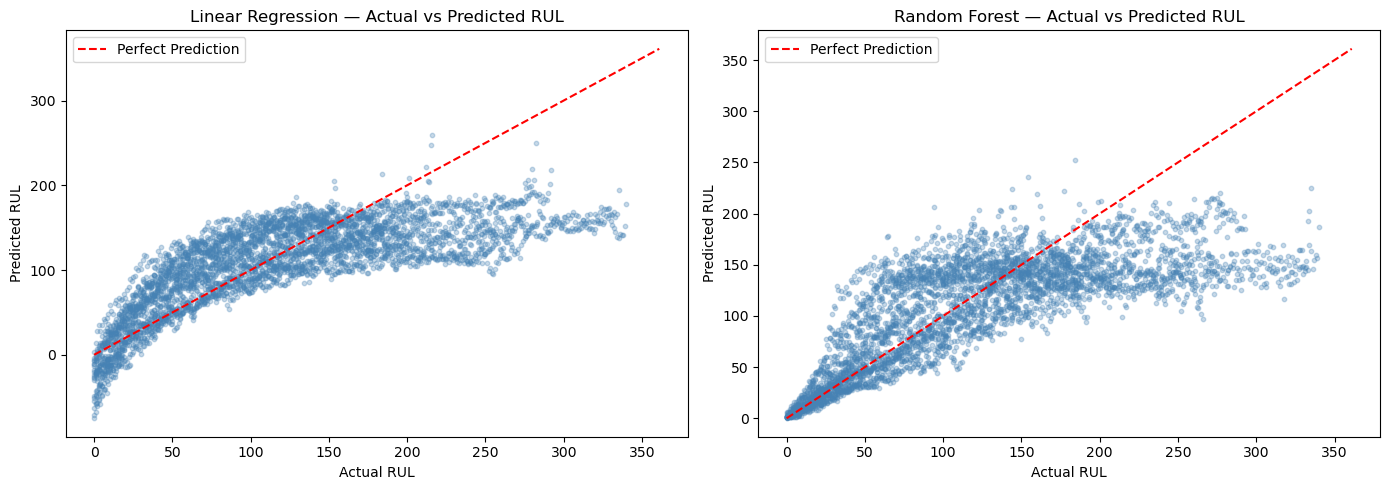

In [7]:
# ============================================================
# TRAIN MODELS — LINEAR REGRESSION & RANDOM FOREST
# ============================================================

# Model 1: Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
lr_preds = lr_model.predict(X_test_scaled)

lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))
lr_r2   = r2_score(y_test, lr_preds)

# Model 2: Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)
rf_preds = rf_model.predict(X_test_scaled)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
rf_r2   = r2_score(y_test, rf_preds)

# Results
print("=" * 45)
print(f"{'Model':<25} {'RMSE':>8} {'R2':>8}")
print("=" * 45)
print(f"{'Linear Regression':<25} {lr_rmse:>8.2f} {lr_r2:>8.4f}")
print(f"{'Random Forest':<25} {rf_rmse:>8.2f} {rf_r2:>8.4f}")
print("=" * 45)

# Visual comparison — Actual vs Predicted
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, preds, title in zip(axes,
                             [lr_preds, rf_preds],
                             ['Linear Regression', 'Random Forest']):
    ax.scatter(y_test, preds, alpha=0.3, color='steelblue', s=10)
    ax.plot([0, 361], [0, 361], 'r--', linewidth=1.5, label='Perfect Prediction')
    ax.set_xlabel('Actual RUL')
    ax.set_ylabel('Predicted RUL')
    ax.set_title(f'{title} — Actual vs Predicted RUL')
    ax.legend()

plt.tight_layout()
plt.show()

Running SHAP analysis (takes 1-2 minutes)...


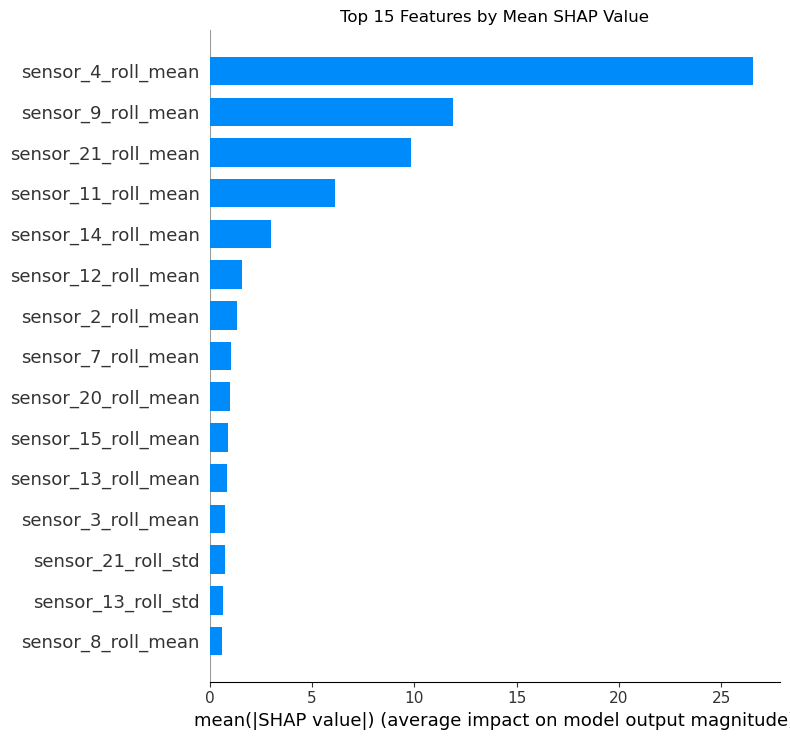

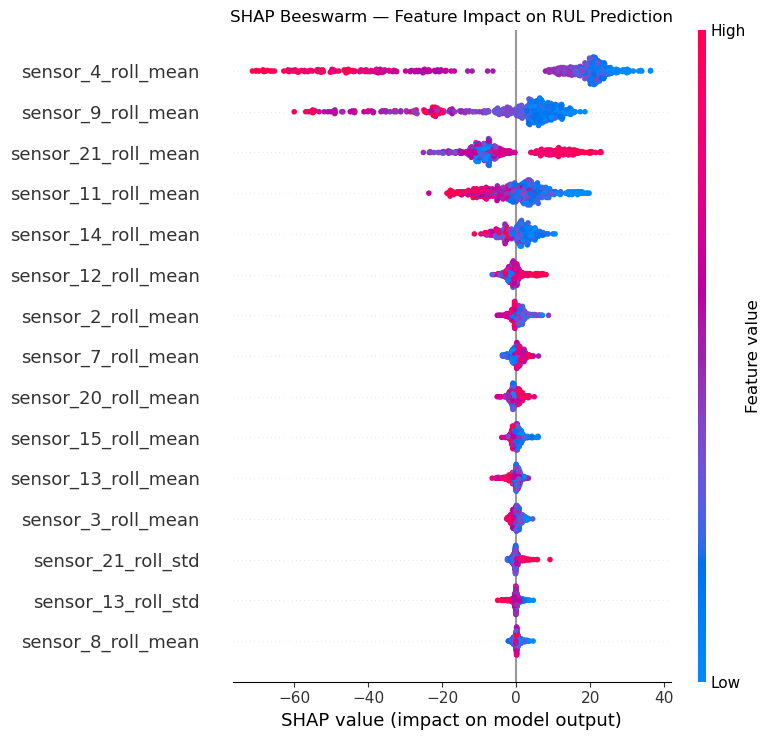

SHAP analysis complete.


In [8]:
# ============================================================
# SHAP — MODEL EXPLAINABILITY
# ============================================================

print("Running SHAP analysis (takes 1-2 minutes)...")

# Use a sample of 500 rows for speed
sample_idx = np.random.choice(X_test_scaled.shape[0], 500, replace=False)
X_sample = X_test_scaled[sample_idx]

# SHAP TreeExplainer works directly with tree-based models
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_sample)

# Plot 1 — Bar chart of top 15 most important features
plt.figure()
shap.summary_plot(shap_values, X_sample, 
                  feature_names=feature_cols,
                  plot_type='bar',
                  max_display=15,
                  show=False)
plt.title('Top 15 Features by Mean SHAP Value')
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

# Plot 2 — Beeswarm plot (shows direction of impact)
plt.figure()
shap.summary_plot(shap_values, X_sample,
                  feature_names=feature_cols,
                  max_display=15,
                  show=False)
plt.title('SHAP Beeswarm — Feature Impact on RUL Prediction')
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

print("SHAP analysis complete.")

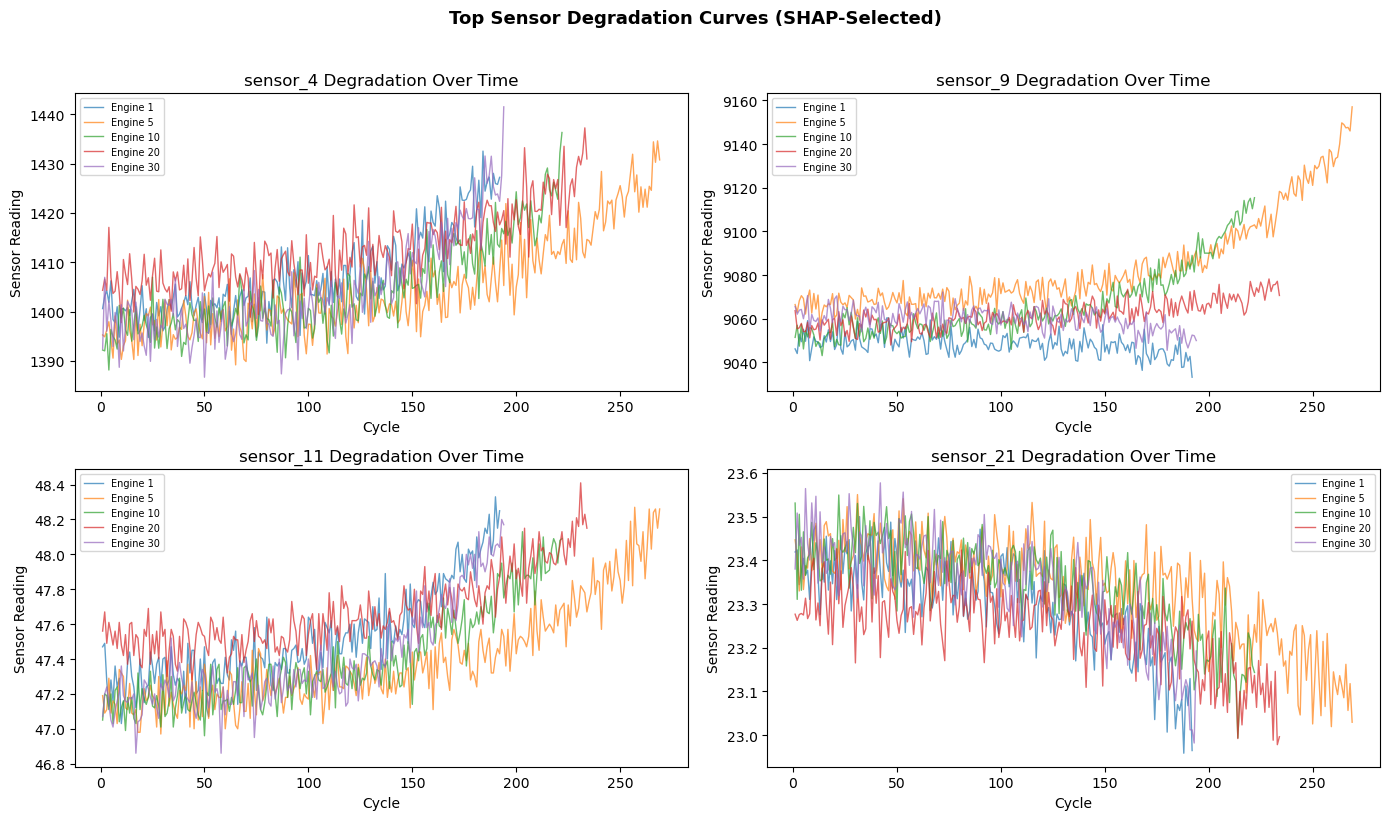

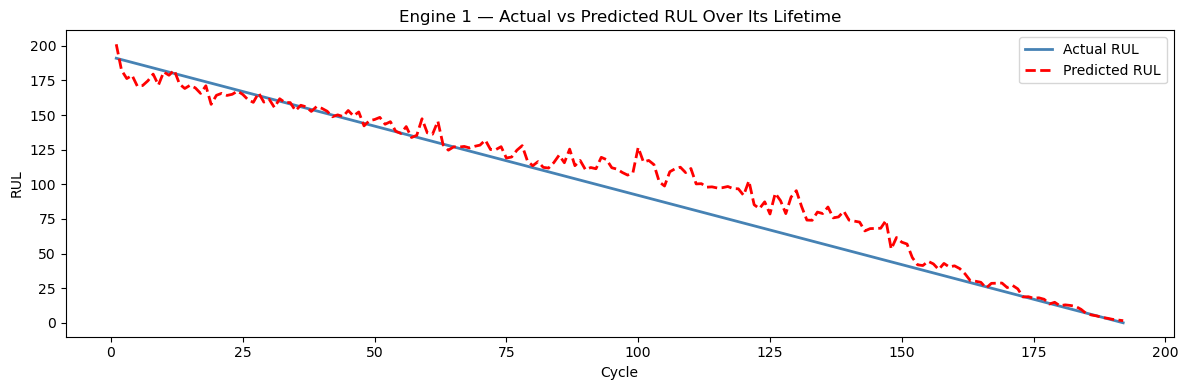

In [9]:
# ============================================================
# VISUALISE ENGINE DEGRADATION OVER TIME
# ============================================================

top_sensors = ['sensor_4', 'sensor_9', 'sensor_11', 'sensor_21']

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for idx, sensor in enumerate(top_sensors):
    ax = axes[idx]
    # Plot 5 random engines
    for eng_id in [1, 5, 10, 20, 30]:
        eng_data = train_df[train_df['engine_id'] == eng_id]
        ax.plot(eng_data['cycle'], eng_data[sensor], alpha=0.7, linewidth=1)
    
    ax.set_xlabel('Cycle')
    ax.set_ylabel('Sensor Reading')
    ax.set_title(f'{sensor} Degradation Over Time')
    ax.legend([f'Engine {i}' for i in [1, 5, 10, 20, 30]], 
              fontsize=7, loc='best')

plt.suptitle('Top Sensor Degradation Curves (SHAP-Selected)', 
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('degradation_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# RUL prediction for a single engine — actual vs predicted
engine_test = train_df[train_df['engine_id'] == 1].copy()
X_eng = engine_test[feature_cols]
X_eng_scaled = scaler.transform(X_eng)
engine_test['RF_Predicted_RUL'] = rf_model.predict(X_eng_scaled)

plt.figure(figsize=(12, 4))
plt.plot(engine_test['cycle'], engine_test['RUL'], 
         label='Actual RUL', color='steelblue', linewidth=2)
plt.plot(engine_test['cycle'], engine_test['RF_Predicted_RUL'], 
         label='Predicted RUL', color='red', linewidth=2, linestyle='--')
plt.xlabel('Cycle')
plt.ylabel('RUL')
plt.title('Engine 1 — Actual vs Predicted RUL Over Its Lifetime')
plt.legend()
plt.tight_layout()
plt.savefig('engine1_rul_prediction.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# ============================================================
# SAVE THE TRAINED MODEL
# ============================================================

import joblib
import os

os.makedirs('models', exist_ok=True)

# Save Random Forest model
joblib.dump(rf_model, 'models/rf_rul_model.pkl')

# Save scaler
joblib.dump(scaler, 'models/scaler.pkl')

# Save feature column names
joblib.dump(feature_cols, 'models/feature_cols.pkl')

print("Model saved: models/rf_rul_model.pkl")
print("Scaler saved: models/scaler.pkl")
print("Feature cols saved: models/feature_cols.pkl")

# Verify saved model loads correctly
loaded_model = joblib.load('models/rf_rul_model.pkl')
loaded_scaler = joblib.load('models/scaler.pkl')
test_pred = loaded_model.predict(loaded_scaler.transform(X_test[:5]))
print(f"\nVerification — predictions from loaded model: {test_pred.round(1)}")
print("Model loading verified successfully.")

Model saved: models/rf_rul_model.pkl
Scaler saved: models/scaler.pkl
Feature cols saved: models/feature_cols.pkl

Verification — predictions from loaded model: [106.3 110.  109.5 102.7 108.9]
Model loading verified successfully.


In [12]:
# ============================================================
# FINAL RESULTS SUMMARY
# ============================================================

print("=" * 50)
print("   PREDICTIVE MAINTENANCE — PROJECT SUMMARY")
print("=" * 50)
print(f"\nDataset   : NASA C-MAPSS FD001")
print(f"Engines   : 100")
print(f"Records   : 20,631")
print(f"Features  : {len(feature_cols)} (after engineering)")
print(f"\nModel Performance:")
print(f"  Linear Regression  — RMSE: {lr_rmse:.2f}  R2: {lr_r2:.4f}")
print(f"  Random Forest      — RMSE: {rf_rmse:.2f}  R2: {rf_r2:.4f}")
print(f"\nBest Model : Random Forest")
print(f"Top Sensor : sensor_4_roll_mean (SHAP)")
print(f"\nOutputs saved:")
print(f"  models/rf_rul_model.pkl")
print(f"  models/scaler.pkl")
print(f"  shap_bar.png")
print(f"  shap_beeswarm.png")
print(f"  degradation_curves.png")
print(f"  engine1_rul_prediction.png")
print("=" * 50)
print("Project complete.")

   PREDICTIVE MAINTENANCE — PROJECT SUMMARY

Dataset   : NASA C-MAPSS FD001
Engines   : 100
Records   : 20,631
Features  : 57 (after engineering)

Model Performance:
  Linear Regression  — RMSE: 53.71  R2: 0.5339
  Random Forest      — RMSE: 52.29  R2: 0.5581

Best Model : Random Forest
Top Sensor : sensor_4_roll_mean (SHAP)

Outputs saved:
  models/rf_rul_model.pkl
  models/scaler.pkl
  shap_bar.png
  shap_beeswarm.png
  degradation_curves.png
  engine1_rul_prediction.png
Project complete.
